Build and train a Fourier Neural Operator (FNO) in PyTorch to predict two-dimensional fluid flow through unseen pipe geometries. This end-to-end project demonstrates field-to-field learning, learnable spectral convolutions in the Fourier domain, Fourier blocks, local 1×1 convolution paths, lifting and projection layers, synthetic dataset generation, model training, evaluation, and visualization of predicted flow fields.

Using device: cpu

Creating synthetic pipe-flow data...
Training input shape:  torch.Size([256, 32, 32, 3])
Training output shape: torch.Size([256, 32, 32, 2])

Training the Fourier Neural Operator...
Epoch [01/25], Training Loss: 0.044400
Epoch [05/25], Training Loss: 0.002948
Epoch [10/25], Training Loss: 0.000956
Epoch [15/25], Training Loss: 0.000515
Epoch [20/25], Training Loss: 0.000324
Epoch [25/25], Training Loss: 0.000201
Training complete.

Average Test Loss: 0.000178

Input shape: torch.Size([1, 32, 32, 3]) -> [batch, height, width, input features]
Predicted output shape: torch.Size([1, 32, 32, 2]) -> [batch, height, width, flow components]

The output is a complete 32 × 32 flow field.
Each grid location contains a predicted horizontal and vertical flow component.


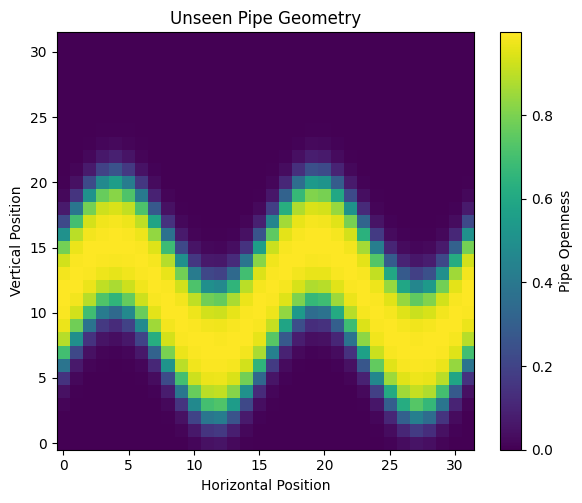

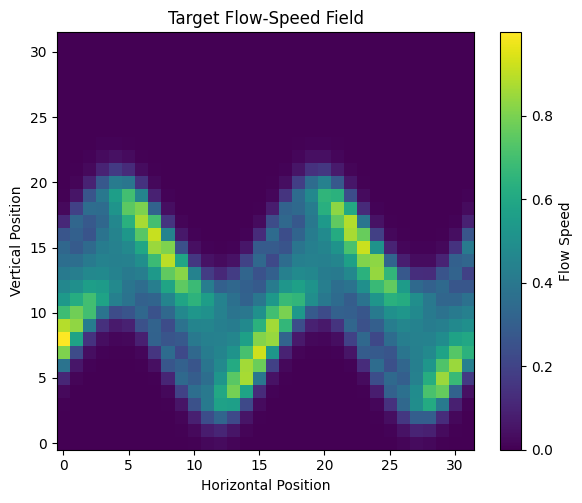

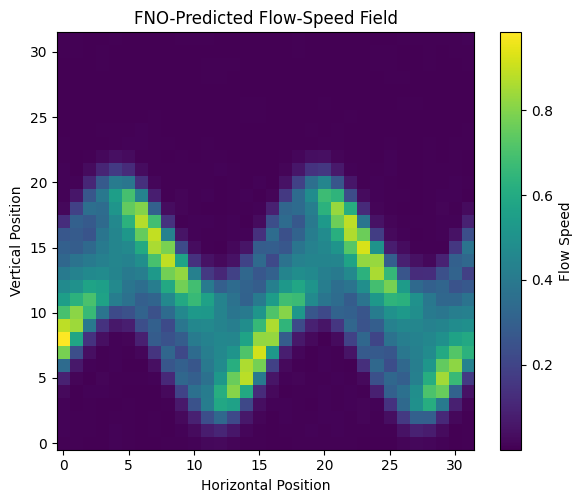

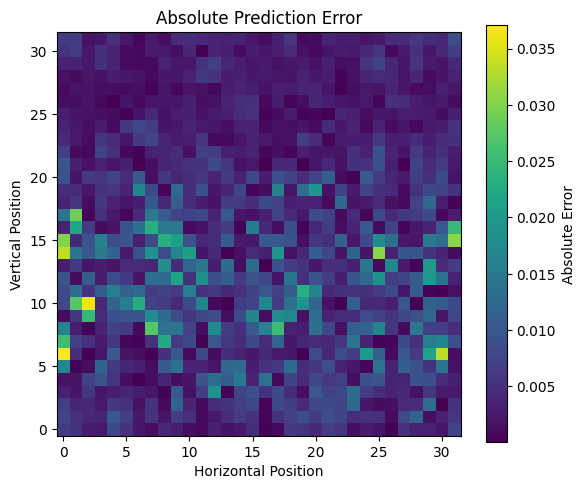

In [1]:
# ===========================================================================
# A Fully Runnable Educational Fourier Neural Operator (FNO)
#
# Problem:
# Learn a mapping from a simplified pipe-layout field and pressure conditions
# to a complete two-dimensional flow field.
#
# Input channels:
#   1. Pipe openness / geometry
#   2. Inlet-pressure contribution
#   3. Outlet-pressure contribution
#
# Output channels:
#   1. Horizontal flow component
#   2. Vertical flow component
#
# This example demonstrates the core FNO workflow:
#
# Input field
#     ↓
# Lift to a richer feature space
#     ↓
# Fourier transform
#     ↓
# Apply learnable complex-valued spectral weights
#     ↓
# Inverse Fourier transform
#     ↓
# Predict an entire output field
#
# Install requirements:
# pip install torch matplotlib
# ===========================================================================

import math
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ===========================================================================
# 1. Reproducibility and Device
# ===========================================================================

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ===========================================================================
# 2. Synthetic Pipe-Flow Dataset
# ===========================================================================

def smooth_field(field, smoothing_strength=0.08):
    """
    Smooths a 2D field in the Fourier domain.

    Low spatial frequencies represent broad, smooth patterns.
    High spatial frequencies represent sharp local variation.

    The exponential filter suppresses high-frequency components,
    producing a smooth field similar to what might occur in a
    physical pressure or geometry distribution.
    """

    height, width = field.shape[-2:]

    frequencies_y = torch.fft.fftfreq(height, device=field.device)
    frequencies_x = torch.fft.rfftfreq(width, device=field.device)

    frequency_radius_squared = (
        frequencies_y[:, None] ** 2
        + frequencies_x[None, :] ** 2
    )

    smoothing_filter = torch.exp(
        -frequency_radius_squared / smoothing_strength
    )

    field_fft = torch.fft.rfft2(field)
    smoothed_fft = field_fft * smoothing_filter
    smoothed = torch.fft.irfft2(
        smoothed_fft,
        s=(height, width)
    )

    return smoothed

def create_single_example(grid_size=32):
    """
    Creates one simplified pipe-flow example.

    The input field contains:
        channel 0: pipe openness / geometry
        channel 1: inlet-pressure contribution
        channel 2: outlet-pressure contribution

    The output field contains:
        channel 0: horizontal flow
        channel 1: vertical flow

    This is not a full Navier-Stokes simulation. Instead, it creates a
    simplified physics-inspired target in which water tends to move from
    high pressure to low pressure and flows more easily through open regions.
    """

    # Spatial coordinates from 0 to 1.
    y = torch.linspace(0, 1, grid_size)
    x = torch.linspace(0, 1, grid_size)

    yy, xx = torch.meshgrid(
        y,
        x,
        indexing="ij"
    )

    # -----------------------------------------------------------------------
    # Create a smooth, curved pipe region.
    # -----------------------------------------------------------------------

    # Random centerline parameters make every pipe layout different.
    center_offset = random.uniform(0.35, 0.65)
    wave_amplitude = random.uniform(0.05, 0.18)
    wave_frequency = random.randint(1, 3)
    pipe_width = random.uniform(0.12, 0.22)

    centerline = (
        center_offset
        + wave_amplitude
        * torch.sin(
            2 * math.pi * wave_frequency * xx
        )
    )

    distance_from_centerline = torch.abs(yy - centerline)

    # A smooth mask:
    # values near 1 indicate open pipe,
    # values near 0 indicate solid material.
    openness = torch.sigmoid(
        (pipe_width - distance_from_centerline) * 40
    )

    # -----------------------------------------------------------------------
    # Define pressure conditions.
    # -----------------------------------------------------------------------

    inlet_pressure = random.uniform(0.8, 1.2)
    outlet_pressure = random.uniform(0.0, 0.3)

    # Pressure generally decreases from left to right.
    base_pressure = (
        inlet_pressure * (1.0 - xx)
        + outlet_pressure * xx
    )

    # Add a geometry-dependent pressure variation.
    geometry_effect = smooth_field(
        openness.unsqueeze(0)
    ).squeeze(0)

    pressure = (
        base_pressure
        + 0.15 * geometry_effect
    )

    # -----------------------------------------------------------------------
    # Compute a simplified flow field.
    #
    # Fluid tends to move down the pressure gradient:
    #
    # flow ≈ -openness × gradient(pressure)
    # -----------------------------------------------------------------------

    pressure_gradient_y, pressure_gradient_x = torch.gradient(
        pressure,
        spacing=(1.0 / grid_size, 1.0 / grid_size)
    )

    flow_x = -openness * pressure_gradient_x
    flow_y = -openness * pressure_gradient_y

    # Normalize the flow so the learning problem remains numerically stable.
    scale = torch.max(
        torch.sqrt(flow_x ** 2 + flow_y ** 2)
    ).clamp_min(1e-6)

    flow_x = flow_x / scale
    flow_y = flow_y / scale

    # Separate pressure information into inlet and outlet channels.
    inlet_field = inlet_pressure * (1.0 - xx)
    outlet_field = outlet_pressure * xx

    # Input shape: [height, width, 3]
    input_field = torch.stack(
        [
            openness,
            inlet_field,
            outlet_field
        ],
        dim=-1
    )

    # Output shape: [height, width, 2]
    output_field = torch.stack(
        [
            flow_x,
            flow_y
        ],
        dim=-1
    )

    return input_field, output_field

def create_dataset(num_samples, grid_size=32):
    """
    Creates many input-function and output-function pairs.
    """

    inputs = []
    outputs = []

    for _ in range(num_samples):
        input_field, output_field = create_single_example(
            grid_size=grid_size
        )

        inputs.append(input_field)
        outputs.append(output_field)

    return (
        torch.stack(inputs),
        torch.stack(outputs)
    )

# ===========================================================================
# 3. Learned Spectral Convolution Layer
# ===========================================================================

class SpectralConv2d(nn.Module):
    """
    A true learnable Fourier layer.

    The layer:

        1. transforms the input into Fourier space,
        2. multiplies selected Fourier coefficients by learned
           complex-valued weights,
        3. converts the result back into spatial space.

    This learned multiplication is the central operation of an FNO.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        modes_y,
        modes_x
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_y = modes_y
        self.modes_x = modes_x

        # Complex-valued weights for positive vertical frequencies.
        self.weights_positive = nn.Parameter(
            self._initialize_complex_weights()
        )

        # Complex-valued weights for negative vertical frequencies.
        self.weights_negative = nn.Parameter(
            self._initialize_complex_weights()
        )

    def _initialize_complex_weights(self):
        """
        Initializes small complex-valued spectral weights.
        """

        scale = 1.0 / (
            self.in_channels * self.out_channels
        )

        real_part = scale * torch.randn(
            self.in_channels,
            self.out_channels,
            self.modes_y,
            self.modes_x
        )

        imaginary_part = scale * torch.randn(
            self.in_channels,
            self.out_channels,
            self.modes_y,
            self.modes_x
        )

        return torch.complex(
            real_part,
            imaginary_part
        )

    @staticmethod
    def complex_multiply(input_fft, weights):
        """
        Multiplies Fourier coefficients by learned complex weights.

        Input:
            [batch, in_channels, modes_y, modes_x]

        Weights:
            [in_channels, out_channels, modes_y, modes_x]

        Output:
            [batch, out_channels, modes_y, modes_x]
        """

        return torch.einsum(
            "bixy,ioxy->boxy",
            input_fft,
            weights
        )

    def forward(self, x):
        """
        Args:
            x:
                Spatial input with shape
                [batch, channels, height, width]

        Returns:
            Spatial output with shape
            [batch, out_channels, height, width]
        """

        batch_size, _, height, width = x.shape

        # ---------------------------------------------------------------
        # Step 1: Convert the spatial field to Fourier space.
        #
        # rfft2 is used because the spatial input is real-valued.
        # The output is complex-valued.
        # ---------------------------------------------------------------

        x_fft = torch.fft.rfft2(
            x,
            dim=(-2, -1),
            norm="ortho"
        )

        # Create an empty Fourier output.
        output_fft = torch.zeros(
            batch_size,
            self.out_channels,
            height,
            width // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        # ---------------------------------------------------------------
        # Step 2: Apply learned weights to selected Fourier modes.
        #
        # The model learns how broad spatial patterns and finer patterns
        # should contribute to the output field.
        # ---------------------------------------------------------------

        output_fft[
            :,
            :,
            :self.modes_y,
            :self.modes_x
        ] = self.complex_multiply(
            x_fft[
                :,
                :,
                :self.modes_y,
                :self.modes_x
            ],
            self.weights_positive
        )

        output_fft[
            :,
            :,
            -self.modes_y:,
            :self.modes_x
        ] = self.complex_multiply(
            x_fft[
                :,
                :,
                -self.modes_y:,
                :self.modes_x
            ],
            self.weights_negative
        )

        # ---------------------------------------------------------------
        # Step 3: Convert the learned frequency representation back
        # into spatial coordinates.
        # ---------------------------------------------------------------

        output = torch.fft.irfft2(
            output_fft,
            s=(height, width),
            dim=(-2, -1),
            norm="ortho"
        )

        return output

# ===========================================================================
# 4. Fourier Neural Operator
# ===========================================================================

class SimpleFNO(nn.Module):
    """
    A compact educational Fourier Neural Operator.

    It maps an entire input field to an entire output field.

    Input:
        [batch, height, width, input_channels]

    Output:
        [batch, height, width, output_channels]
    """

    def __init__(
        self,
        in_channels=3,
        out_channels=2,
        width=24,
        modes_y=10,
        modes_x=10
    ):
        super().__init__()

        self.width = width

        # ---------------------------------------------------------------
        # Lifting layer:
        #
        # Each grid point begins with only three values.
        # This layer maps those values into a richer feature space.
        # ---------------------------------------------------------------

        self.lifting = nn.Linear(
            in_channels,
            width
        )

        # Fourier layers learn non-local, global spatial relationships.
        self.spectral1 = SpectralConv2d(
            width,
            width,
            modes_y,
            modes_x
        )

        self.spectral2 = SpectralConv2d(
            width,
            width,
            modes_y,
            modes_x
        )

        self.spectral3 = SpectralConv2d(
            width,
            width,
            modes_y,
            modes_x
        )

        # Pointwise 1 × 1 convolutions learn local feature combinations.
        self.local1 = nn.Conv2d(
            width,
            width,
            kernel_size=1
        )

        self.local2 = nn.Conv2d(
            width,
            width,
            kernel_size=1
        )

        self.local3 = nn.Conv2d(
            width,
            width,
            kernel_size=1
        )

        self.activation = nn.GELU()

        # Projection layers convert internal features to output fields.
        self.projection1 = nn.Linear(
            width,
            64
        )

        self.projection2 = nn.Linear(
            64,
            out_channels
        )

    def forward(self, x):
        """
        Performs a field-to-field prediction.
        """

        # Input:
        # [batch, height, width, input_channels]

        x = self.lifting(x)

        # After lifting:
        # [batch, height, width, width]

        # PyTorch convolution and FFT layers expect channels first.
        x = x.permute(0, 3, 1, 2)

        # Shape:
        # [batch, width, height, width]

        # Each block combines:
        #
        # spectral path: global spatial information
        # local path:    local pointwise information

        x = self.activation(
            self.spectral1(x) + self.local1(x)
        )

        x = self.activation(
            self.spectral2(x) + self.local2(x)
        )

        x = self.activation(
            self.spectral3(x) + self.local3(x)
        )

        # Convert back to channels-last format.
        x = x.permute(0, 2, 3, 1)

        # Project to the two flow components.
        x = self.activation(
            self.projection1(x)
        )

        output = self.projection2(x)

        return output

# ===========================================================================
# 5. Create Training and Test Data
# ===========================================================================

grid_size = 32

print("\nCreating synthetic pipe-flow data...")

train_inputs, train_outputs = create_dataset(
    num_samples=256,
    grid_size=grid_size
)

test_inputs, test_outputs = create_dataset(
    num_samples=32,
    grid_size=grid_size
)

train_dataset = TensorDataset(
    train_inputs,
    train_outputs
)

test_dataset = TensorDataset(
    test_inputs,
    test_outputs
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print(
    f"Training input shape:  {train_inputs.shape}"
)

print(
    f"Training output shape: {train_outputs.shape}"
)

# ===========================================================================
# 6. Initialize the FNO
# ===========================================================================

model = SimpleFNO(
    in_channels=3,
    out_channels=2,
    width=24,
    modes_y=10,
    modes_x=10
).to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ===========================================================================
# 7. Train the FNO
# ===========================================================================

num_epochs = 25

print("\nTraining the Fourier Neural Operator...")

for epoch in range(num_epochs):
    model.train()

    total_loss = 0.0

    for input_fields, target_fields in train_loader:
        input_fields = input_fields.to(device)
        target_fields = target_fields.to(device)

        # Predict the complete flow field.
        predicted_fields = model(input_fields)

        # Compare every predicted grid value with the target field.
        loss = criterion(
            predicted_fields,
            target_fields
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * input_fields.size(0)
        )

    average_train_loss = (
        total_loss / len(train_loader.dataset)
    )

    if (
        epoch == 0
        or (epoch + 1) % 5 == 0
    ):
        print(
            f"Epoch [{epoch + 1:02d}/{num_epochs}], "
            f"Training Loss: {average_train_loss:.6f}"
        )

print("Training complete.")

# ===========================================================================
# 8. Evaluate on Unseen Pipe Layouts
# ===========================================================================

model.eval()

test_loss = 0.0

with torch.no_grad():
    for input_fields, target_fields in test_loader:
        input_fields = input_fields.to(device)
        target_fields = target_fields.to(device)

        predicted_fields = model(input_fields)

        loss = criterion(
            predicted_fields,
            target_fields
        )

        test_loss += (
            loss.item() * input_fields.size(0)
        )

average_test_loss = (
    test_loss / len(test_loader.dataset)
)

print(
    f"\nAverage Test Loss: {average_test_loss:.6f}"
)

# ===========================================================================
# 9. Predict One New Flow Field
# ===========================================================================

sample_input = test_inputs[0:1].to(device)
sample_target = test_outputs[0:1].to(device)

with torch.no_grad():
    sample_prediction = model(sample_input)

print(
    f"\nInput shape: {sample_input.shape} "
    "-> [batch, height, width, input features]"
)

print(
    f"Predicted output shape: {sample_prediction.shape} "
    "-> [batch, height, width, flow components]"
)

print(
    "\nThe output is a complete 32 × 32 flow field."
)

print(
    "Each grid location contains a predicted horizontal "
    "and vertical flow component."
)

# ===========================================================================
# 10. Visualize the Result
# ===========================================================================

sample_input_cpu = sample_input.cpu()[0]
sample_target_cpu = sample_target.cpu()[0]
sample_prediction_cpu = sample_prediction.cpu()[0]

pipe_geometry = sample_input_cpu[:, :, 0]

target_speed = torch.sqrt(
    sample_target_cpu[:, :, 0] ** 2
    + sample_target_cpu[:, :, 1] ** 2
)

predicted_speed = torch.sqrt(
    sample_prediction_cpu[:, :, 0] ** 2
    + sample_prediction_cpu[:, :, 1] ** 2
)

absolute_error = torch.abs(
    predicted_speed - target_speed
)

plt.figure(figsize=(6, 5))
plt.imshow(
    pipe_geometry,
    origin="lower"
)
plt.title("Unseen Pipe Geometry")
plt.xlabel("Horizontal Position")
plt.ylabel("Vertical Position")
plt.colorbar(label="Pipe Openness")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(
    target_speed,
    origin="lower"
)
plt.title("Target Flow-Speed Field")
plt.xlabel("Horizontal Position")
plt.ylabel("Vertical Position")
plt.colorbar(label="Flow Speed")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(
    predicted_speed,
    origin="lower"
)
plt.title("FNO-Predicted Flow-Speed Field")
plt.xlabel("Horizontal Position")
plt.ylabel("Vertical Position")
plt.colorbar(label="Flow Speed")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(
    absolute_error,
    origin="lower"
)
plt.title("Absolute Prediction Error")
plt.xlabel("Horizontal Position")
plt.ylabel("Vertical Position")
plt.colorbar(label="Absolute Error")
plt.tight_layout()
plt.show()

